# UC Berkeley Capstone Project -- Data Analysis & Modelling

This is a notebook for my UC Berkeley Capstone project.

I have a harvester script running in GCP that collects YouTube video metadata and metrics and stores that in a BQ table. 
Because the script is running in an ongoing basis, and I have limited time before I need to turn in the project, I am going to start working with synthetic data integrated with my real data, and gradually shift over to all real data.

- This will allow me start modelling sooner. 
- The synthetic data will be identifiable in the DataFrame.
- I will be storing a Parquet snapshot of the BQ data extract + model version in a GCS Bucket, so that I can always see which specific data + model produced which specific results.

The workflow here is:

1. Create a snapshot of the BQ data 
1. Add the synthetic data rows
1. Store the dataset in a versioned GCS bucket
1. (when modelling) store model vesrion data + stats in a versioned GCS bucket as well.

TODO (jelani):

1. make the snapshotting proces easier to manage with a global flag for on/off and constants for the different model version names, video snapshog version names, etc. The on/off can live in each code blcok where it is needed so that I'm not hunting through code to update it. 
1. Have this all live in a cell at the top of the notebook to make it easy to access and change.
1. Add the newer cut of real data
1. Make the label for synth data split easier to figure out (and set some math to do the split)
1. Add RnadomForrest


In [ ]:
import math
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import utils.snapshot_data as snapshot
from utils.snapshot_model import (
    TrainingData, ModelResult, ModelConfig,
    save_model, list_models, compare_models,
)
from utils.snapshot_hyperparameters import save_hyperparams, load_hyperparams, list_hyperparams
from utils.snapshot_config import SnapshotConfig
#from utils.snapshot_config import DEFAULT_LR_PARAMS_, DEFAULT_RF_PARAMS_, DEFAULT_XGB_PARAMS_

from utils.tune_hyperparameters import tune_model, get_default_param_grid

from data_processing.data_cleanup import build_clean_dataset
from data_processing.feature_engineering import engineer_features
from data_processing.synthetic_data import generate_synthetic_data, combine_real_and_synthetic

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay,
)
from xgboost import XGBClassifier

In [ ]:
RANDOM_SEED = 42

# =============================================================================
# SNAPSHOT CONFIG
# Controls which snapshots are written to GCS this run, and what version they get.
# Version numbers are read from (and written back to) GCS config/versions.json.
#
# Presets:
#   "dry_run"             — no snapshots; uses current versions for reading
#   "model_tuning"        — models + hyperparams        → minor bump (e.g. 3.1 → 3.2)
#   "feature_engineering" — mixed + models + hyperparams → minor bump
#   "new_raw_data"        — all four                    → major bump (e.g. 3.1 → 4.0)
#
# Or chain methods explicitly:
#   config = SnapshotConfig.load().snapshot_mixed().snapshot_models().build()
# =============================================================================

config = SnapshotConfig.load().preset("dry_run").build()

TIER_ORDER     = ['S', 'M', 'L']
VERTICAL_ORDER = ['Education', 'Lifestyle', 'Tech']

In [3]:
def create_new_snapshot(
    version_name: str, additional_notes: str = ""
):
    """
    Creates snapshots in GCS bucket for:
      - Channel baseline data
      - Channel median data
      - Video snapshot data

    Snapshots can be viewed via `snapshot.list_snapshots` and loaded via
    `snapshot.load_videos` and `snapshot.load_baselines`

    version_name: Name like 'v1.0_real'
    additional_notes: Descriptive notes. `version_name` is automatically added.

    Returns: (video_df, baseline_df, median_df, video_meta, baseline_meta)
    """
    video_df, video_meta = snapshot.snapshot_video_data(version_tag=version_name, 
            notes=f"Video data version {version_name}. {additional_notes}",
    )

    baseline_df, median_df, baseline_meta = snapshot.snapshot_baselines(
        version_tag=version_name,
        notes=f"Channel baselines corresponding to {version_name} video snapshot. {additional_notes}",
    )
    return (video_df, baseline_df, median_df, video_meta, baseline_meta)

In [ ]:
if config.take_snapshot_raw:
    additional_notes = "More triplet rows from a few additional days."
    video_df, baseline_df, median_df, video_meta, baseline_meta = create_new_snapshot(
        version_name=config.raw_version, additional_notes=additional_notes
    )

# See what's available
snapshot.list_snapshots()

In [ ]:
# Load an existing snapshot (no new version created) when loading this notebook.
df_videos, meta = snapshot.load_videos(config.raw_version)
df_baselines, df_medians, baseline_meta = snapshot.load_baselines(config.raw_version)

print(f"Video snapshots: {len(df_videos)}")
print(f"Baseline videos: {len(df_baselines)}")
print(f"Baseline medians: {len(df_medians)}")

df_videos.head()

In [6]:
df_baselines.head()

,channel_id,channel_handle,vertical,tier,video_id,title,published_at,duration_seconds,category_id,category_name,view_count,like_count,comment_count,subscriber_count,baseline_polled_at
0,UChICxLstKUHBhkfoEuOn0wg,@beatphysics,Education,S,O9v-jrknqfI,"Compound Formulas & Naming Explained (Ionic, ...",2026-03-04 01:00:20+00:00,1199,24,Entertainment,25,4,2,3100,2026-03-13 06:48:44.305022+00:00
1,UChICxLstKUHBhkfoEuOn0wg,@beatphysics,Education,S,gxXqC4jhJMw,"Covalent Compounds (Concepts, Formulas, & Nami...",2026-02-26 20:14:06+00:00,444,24,Entertainment,9,3,0,3100,2026-03-13 06:48:44.305022+00:00
2,UChICxLstKUHBhkfoEuOn0wg,@beatphysics,Education,S,WFV-sjHKgKw,Polyatomic Ions (Writing Compound Formulas & N...,2026-02-26 00:00:39+00:00,557,24,Entertainment,33,3,0,3100,2026-03-13 06:48:44.305022+00:00
3,UChICxLstKUHBhkfoEuOn0wg,@beatphysics,Education,S,Mi4iKzZ1w9M,"Ionic Compounds (Formulas, Naming, & Transitio...",2026-02-25 00:00:33+00:00,892,24,Entertainment,13,3,0,3100,2026-03-13 06:48:44.305022+00:00
4,UChICxLstKUHBhkfoEuOn0wg,@beatphysics,Education,S,N5DlbERakjc,"4 Rotation Examples (Kinematics, Torque, Momen...",2026-02-19 20:16:16+00:00,1401,24,Entertainment,23,2,0,3100,2026-03-13 06:48:44.305022+00:00


In [7]:
df_medians.head()

,channel_id,channel_handle,baseline_video_count,median_views,median_likes,median_comments,median_engagement_rate
0,UChICxLstKUHBhkfoEuOn0wg,@beatphysics,30,63,2,0,0.022059
1,UClwfFicJWu0SF33fkks9Ufg,@mealpreponfleek,30,2866,41,2,0.015188
2,UCPUmTEzr8krG5POZ7nm0tOA,@unitfourzero,30,268,6,1,0.022059
3,UCX5ROxzDUKPuGCk4p-KqFjA,@cybersecuritytelugu,30,303,10,2,0.036160
4,UColPtFDyDoytKMaL88VXiaw,@saasmasterycom,30,1024,23,0,0.030864


In [8]:
print(df_videos.describe())

print(df_videos.info())

          view_count   like_count  comment_count  face_count    brightness  \
count        20612.0      20612.0        20612.0     20612.0  20612.000000   
mean    37139.790025  1300.976713      67.451921    0.834029     77.087307   
std    330312.291084  6948.564158     319.482127    0.999326     28.249234   
min              0.0          0.0            0.0         0.0      0.000000   
25%            250.0         10.0            0.0         0.0     58.851916   
50%           1546.0         69.0            4.0         1.0     75.052633   
75%           9742.5        440.0           25.0         1.0     92.478802   
max       25826937.0     381245.0        12582.0        14.0    213.228414   

       colorfulness  duration_seconds  hours_since_publish  subscriber_count  
count  20612.000000           20612.0         20612.000000           20612.0  
mean      42.453923       1098.445614            47.330897    1470794.312536  
std       23.571466       2643.083078            73.112757  

In [9]:
# Initial cleaning

# NULL value in contains_synthetic_media means that the video couldn't be asssessed (e.g. private or deleted).
# execlude those
df_videos.dropna(subset=["contains_synthetic_media"], inplace=True)

# Build the df with baseline metrics inlined 
df_clean = build_clean_dataset(df_videos, df_medians)
df_model = engineer_features(df_clean)

print(df_model.head())

Building clean dataset

[1/3] Pivoting snapshots...
  Videos with all 3 polls: 4984 (dropped 2886 incomplete)
  Pivoted shape: (5047, 34)

[2/3] Joining baseline medians...
  Baseline join: 5047/5047 videos matched a channel median

[3/3] Cleaning data...
  Cleaned: 5047 rows × 40 columns

Clean dataset: 5047 rows × 40 columns
Engineering features

[1/9] Computing target variable...
  Target distribution: 56.0% above baseline, 44.0% below

[2/9] Computing velocity features...
  Computed velocity, upload momentum, normalized velocity, and acceleration features

[3/9] Computing ratio and baseline-normalized features...
  Computed ratio and baseline-normalized features

[4/9] Computing subscriber-normalized metrics...
  Computed subscriber-normalized metrics for upload/24h/7d

[5/9] Computing categorical features...
  Title categories:
title_category
neutral        3245
exclamation     561
all_caps        533
question        416
listicle        158
how_to           64
clickbait        51


In [10]:
def get_synth_rows_proportion(num_real_rows: int, target_real_pct: float):
    return math.floor(float(num_real_rows) / target_real_pct) - num_real_rows

In [ ]:
target_synth_rows = get_synth_rows_proportion(num_real_rows=len(df_model), target_real_pct=0.8)
print(f"target_synth_rows: {target_synth_rows}")

# Generate synthetic rows (baselines from real channels)
df_synth = generate_synthetic_data(df_model, num_rows=target_synth_rows, seed=RANDOM_SEED)

# Combine
df_combined = combine_real_and_synthetic(df_model, df_synth)

df_combined.sample(8)

In [ ]:
if config.take_snapshot_mixed:
    notes = f"{len(df_model)} real + {target_synth_rows} synthetic (GaussianCopula seed={RANDOM_SEED}), real channel baselines"
    snapshot_meta = snapshot.save_snapshot(
        df=df_combined, version_tag=config.mixed_version, notes=notes
    )

# Load so we aren't creating a snapshot every time the notebook runs
df_combined, _ = snapshot.load_videos(config.mixed_version)

df_train = df_combined

# Never evaluate on synthetic data
df_eval = df_combined[~df_combined["contains_synthetic_data"]]

df_train.sample(5)

In [13]:
# --- Define feature columns (exclude IDs, text, timestamps, target, metadata) ---

# Add 7d metric columns to the exclusion list
EXCLUDE_7D = [c for c in df_combined.columns if c.endswith('_7d')]
print(f"Excluding 7d features: {EXCLUDE_7D}")

EXCLUDE_COLS = [
    # IDs and text
    'video_id', 'channel_id', 'channel_handle', 'title', 'description', 'tags',
    'category_id', 'category_name',
    # Timestamps
    'published_at', 'poll_timestamp_upload', 'poll_timestamp_24h', 'poll_timestamp_7d',
    # Target and intermediate
    'above_baseline', 'engagement_7d', 'baseline_engagement',
    # Metadata flags
    'contains_synthetic_data', 'contains_synthetic_media',
    # Baseline raw (already captured in baseline_engagement)
    'baseline_channel_handle', 'baseline_video_count',
    'baseline_median_views', 'baseline_median_likes',
    'baseline_median_comments', 'baseline_median_engagement_rate',
    # Categorical groupings (use the encoded versions instead)
    'vertical', 'tier',
    # Redundant with duration_seconds
    'duration_minutes',
    # Part of the data harvesting process, not useful for modelling
    'hours_since_publish_upload',
    # Superseded by has_face (binary flag is more reliable signal)
    'face_count',
]

EXCLUDE_COLS.extend(EXCLUDE_7D)

feature_cols = [c for c in df_combined.columns if c not in EXCLUDE_COLS]
print(f"\nFeature columns ({len(feature_cols)}):")
print(feature_cols)

Excluding 7d features: ['view_count_7d', 'like_count_7d', 'comment_count_7d', 'subscriber_count_7d', 'hours_since_publish_7d', 'poll_timestamp_7d', 'engagement_7d', 'views_per_sub_7d', 'likes_per_sub_7d', 'comments_per_sub_7d']

Feature columns (50):
['duration_seconds', 'brightness', 'colorfulness', 'view_count_upload', 'like_count_upload', 'comment_count_upload', 'subscriber_count_upload', 'view_count_24h', 'like_count_24h', 'comment_count_24h', 'subscriber_count_24h', 'hours_since_publish_24h', 'baseline_baseline_video_count', 'view_count_velocity_24h', 'like_count_velocity_24h', 'comment_count_velocity_24h', 'subscriber_count_velocity_24h', 'view_velocity_upload', 'like_velocity_upload', 'view_velocity_per_sub_24h', 'like_velocity_per_sub_24h', 'view_velocity_ratio', 'view_velocity_acceleration', 'like_velocity_acceleration', 'view_count_upload_vs_baseline', 'like_count_upload_vs_baseline', 'like_rate_upload', 'like_rate_24h', 'views_per_sub_upload', 'likes_per_sub_upload', 'commen

## Exploratory Data Analysis

Real data only (synthetic rows excluded). Run after feature engineering to reflect engineered column names.

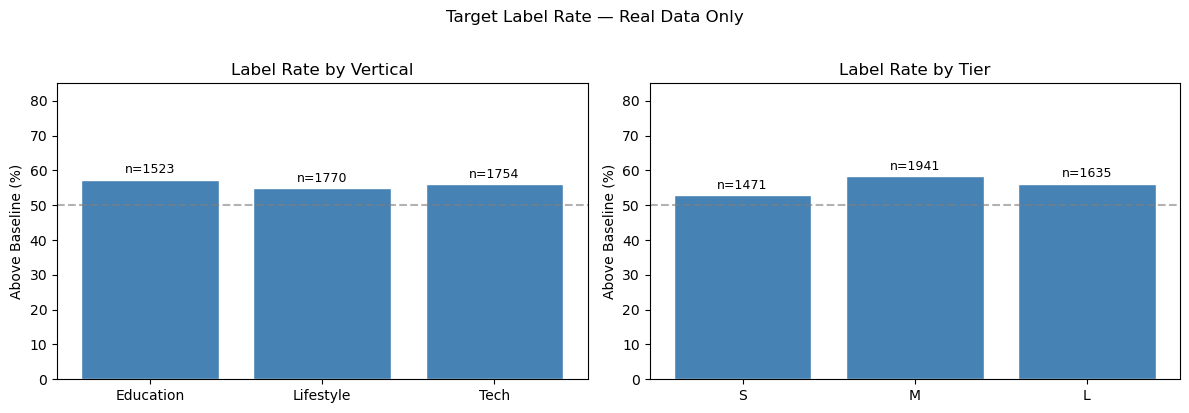

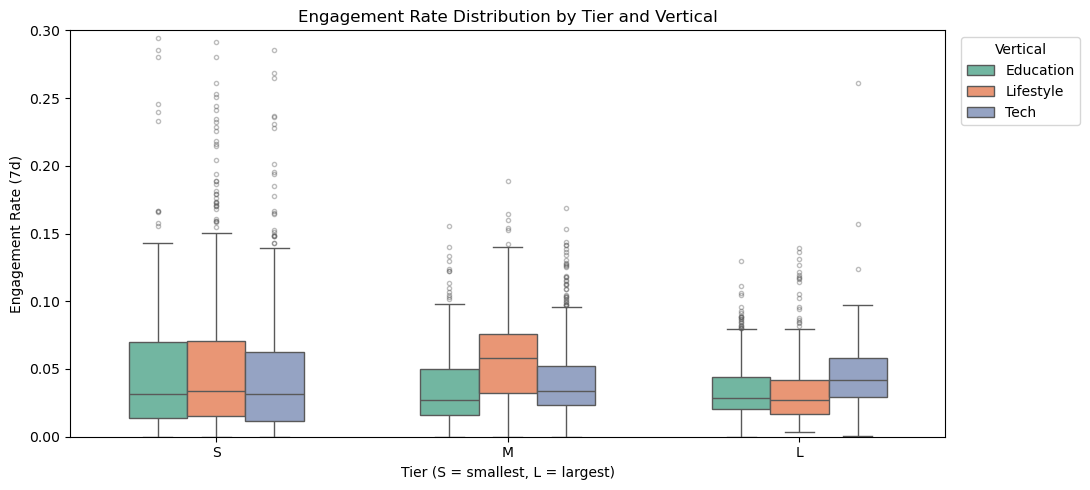

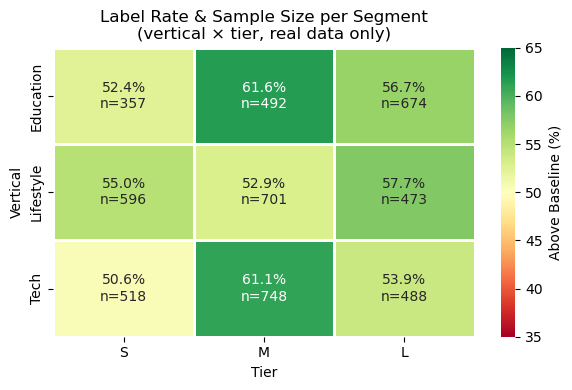

In [14]:
import seaborn as sns

# Real data only for all EDA plots.
# Use df_model (always freshly feature-engineered) rather than df_combined,
# which is loaded from a GCS snapshot and may not have the latest engineered columns.
_df_eda = df_model.copy()

# Sanity check — catch stale df_model before hitting a confusing KeyError mid-plot
_expected_cols = [
    'view_velocity_ratio', 'view_count_velocity_24h', 'view_velocity_acceleration',
    'like_rate_24h', 'view_count_upload_vs_baseline', 'has_face', 'duration_bucket',
]
_missing = [c for c in _expected_cols if c not in _df_eda.columns]
if _missing:
    raise RuntimeError(
        f"df_model is missing engineered columns: {_missing}\n"
        "Re-run the cleaning + feature engineering cells (build_clean_dataset / engineer_features) first."
    )


# =============================================================================
# Plot 1: Above-baseline label rate by vertical and by tier
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, order in [
    (axes[0], 'vertical', VERTICAL_ORDER),
    (axes[1], 'tier',     TIER_ORDER),
]:
    stats = (
        _df_eda.groupby(col)['above_baseline']
        .agg(rate='mean', n='count')
        .reindex(order)
    )
    bars = ax.bar(stats.index, stats['rate'] * 100, color='steelblue', edgecolor='white')
    for bar, (_, row) in zip(bars, stats.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"n={int(row['n'])}",
            ha='center', va='bottom', fontsize=9,
        )
    ax.axhline(50, ls='--', color='gray', alpha=0.6, label='50% reference')
    ax.set_ylabel('Above Baseline (%)')
    ax.set_ylim(0, 85)
    ax.set_title(f'Label Rate by {col.capitalize()}')

plt.suptitle('Target Label Rate — Real Data Only', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


# =============================================================================
# Plot 2: Engagement rate distribution by tier × vertical (box plot)
# Answers: do higher-sub channels (tier) have higher engagement, and does
# that pattern hold consistently across verticals?
# =============================================================================

fig, ax = plt.subplots(figsize=(11, 5))

sns.boxplot(
    data=_df_eda,
    x='tier', y='engagement_7d',
    hue='vertical',
    order=TIER_ORDER,
    hue_order=VERTICAL_ORDER,
    palette='Set2',
    width=0.6,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=ax,
)

ax.set_xlabel('Tier (S = smallest, L = largest)')
ax.set_ylabel('Engagement Rate (7d)')
ax.set_title('Engagement Rate Distribution by Tier and Vertical')
ax.set_ylim(0, 0.3)
ax.legend(title='Vertical', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


# =============================================================================
# Plot 3: Heatmap — label rate and sample size per vertical × tier
# =============================================================================

pivot_rate = (
    _df_eda.groupby(['vertical', 'tier'])['above_baseline']
    .mean()
    .unstack('tier')
    .reindex(index=VERTICAL_ORDER, columns=TIER_ORDER)
    * 100
)
pivot_n = (
    _df_eda.groupby(['vertical', 'tier'])['above_baseline']
    .count()
    .unstack('tier')
    .reindex(index=VERTICAL_ORDER, columns=TIER_ORDER)
)

# Build annotation strings: "XX.X%\nn=YYY"
annot = (
    pivot_rate.round(1).astype(str).add('%\n') +
    'n=' + pivot_n.astype(str)
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    pivot_rate,
    ax=ax,
    annot=annot,
    fmt='',
    cmap='RdYlGn',
    vmin=35, vmax=65,
    linewidths=0.8,
    cbar_kws={'label': 'Above Baseline (%)'},
)
ax.set_title('Label Rate & Sample Size per Segment\n(vertical × tier, real data only)')
ax.set_xlabel('Tier')
ax.set_ylabel('Vertical')
plt.tight_layout()
plt.show()


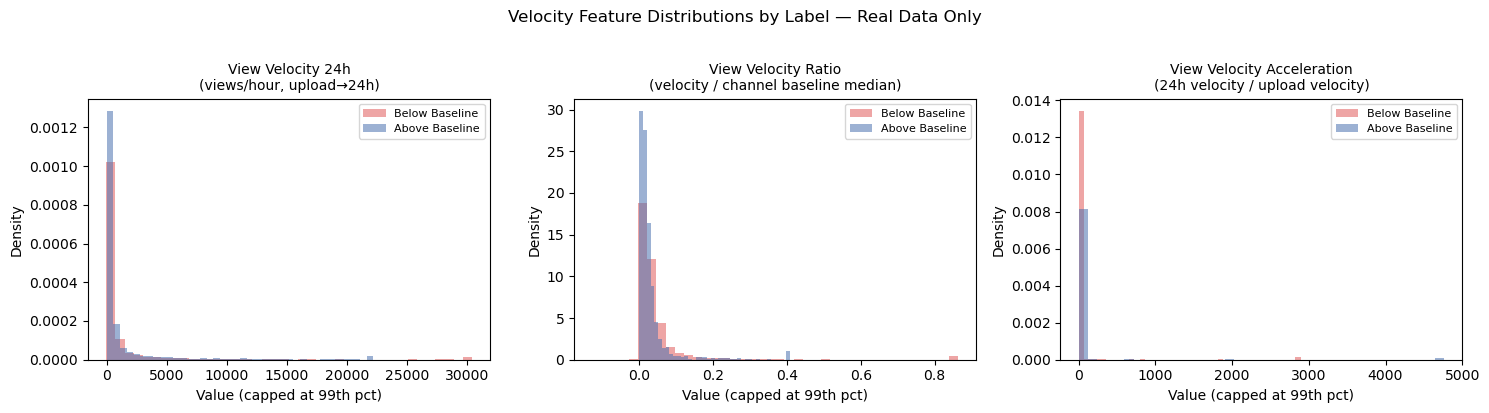

In [15]:
# =============================================================================
# Velocity feature distributions — split by label
# Shows whether each velocity metric is actually discriminative.
# Three features tell the story: raw speed, speed vs channel norm, acceleration.
# =============================================================================

_velocity_features = [
    ('view_count_velocity_24h', 'View Velocity 24h\n(views/hour, upload→24h)'),
    ('view_velocity_ratio',     'View Velocity Ratio\n(velocity / channel baseline median)'),
    ('view_velocity_acceleration', 'View Velocity Acceleration\n(24h velocity / upload velocity)'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (col, title) in zip(axes, _velocity_features):
    for label, color, name in [(0, '#e05c5c', 'Below Baseline'), (1, '#4c72b0', 'Above Baseline')]:
        vals = _df_eda.loc[_df_eda['above_baseline'] == label, col].dropna()
        # Cap at 99th percentile to prevent extreme outliers from flattening the histogram
        cap = vals.quantile(0.99)
        vals = vals.clip(upper=cap)
        ax.hist(vals, bins=40, alpha=0.55, color=color, label=name, density=True)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Value (capped at 99th pct)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Velocity Feature Distributions by Label — Real Data Only', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

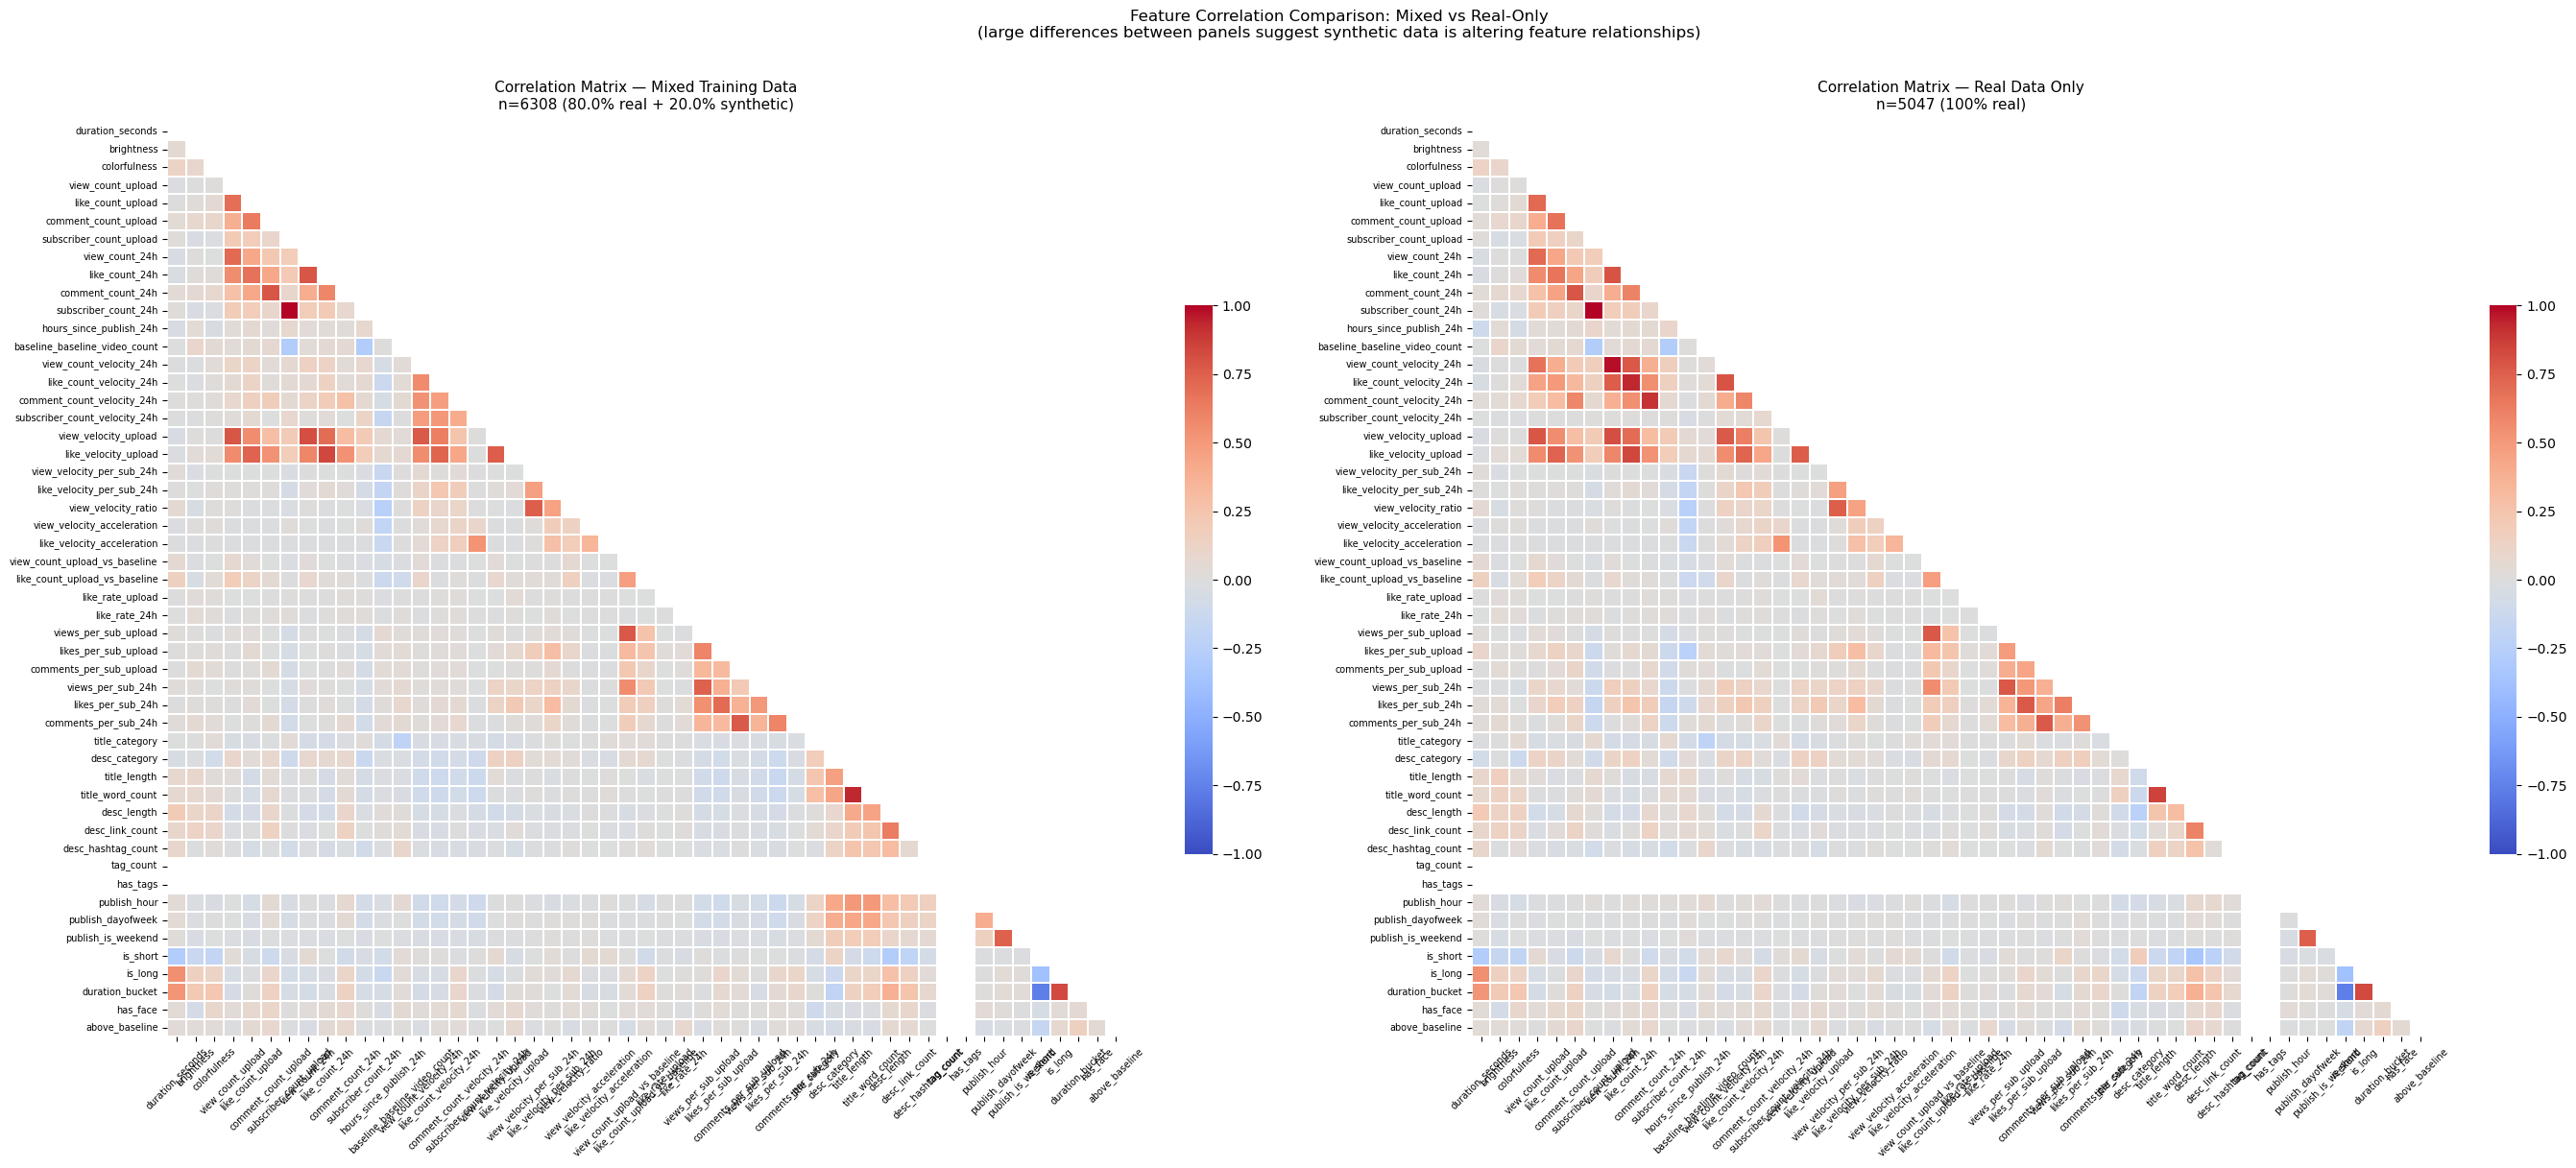

In [16]:
# =============================================================================
# Correlation matrix — mixed (train) data vs real-only data
# Comparing the two shows whether synthetic data is distorting feature relationships.
# =============================================================================

_df_mixed = df_combined[feature_cols + ['above_baseline']].copy()
_df_real  = df_combined[~df_combined['contains_synthetic_data']][feature_cols + ['above_baseline']].copy()

_n_mixed   = len(_df_mixed)
_n_real    = len(_df_real)
_n_synth   = _n_mixed - _n_real
_synth_pct = round(_n_synth / _n_mixed * 100, 1)
_real_pct  = round(_n_real  / _n_mixed * 100, 1)

fig, axes = plt.subplots(1, 2, figsize=(28, 12))

for ax, df_plot, title in [
    (
        axes[0],
        _df_mixed,
        f'Correlation Matrix — Mixed Training Data\n'
        f'n={_n_mixed} ({_real_pct}% real + {_synth_pct}% synthetic)',
    ),
    (
        axes[1],
        _df_real,
        f'Correlation Matrix — Real Data Only\n'
        f'n={_n_real} (100% real)',
    ),
]:
    corr = df_plot.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle only
    sns.heatmap(
        corr,
        ax=ax,
        mask=mask,
        cmap='coolwarm',
        vmin=-1, vmax=1,
        center=0,
        linewidths=0.3,
        annot=False,
        cbar_kws={'shrink': 0.6},
    )
    ax.set_title(title, fontsize=11, pad=10)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle(
    'Feature Correlation Comparison: Mixed vs Real-Only\n'
    '(large differences between panels suggest synthetic data is altering feature relationships)',
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()

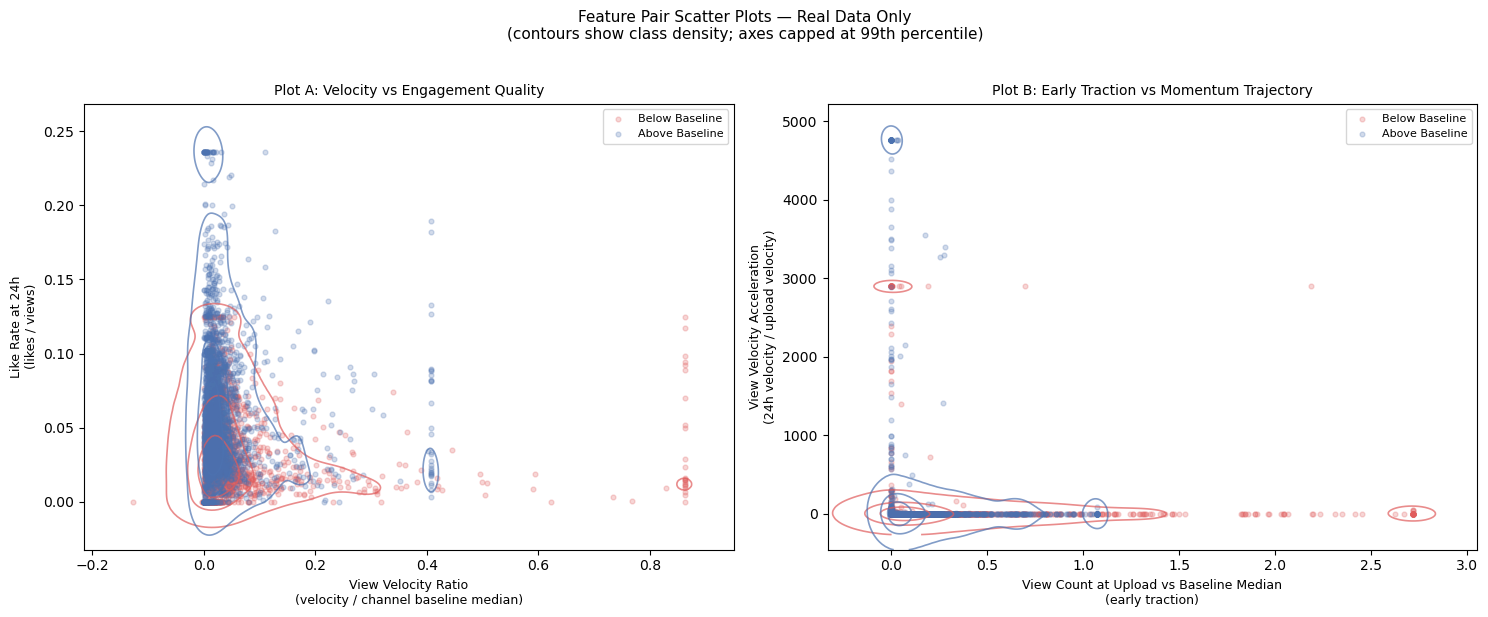

In [17]:
# =============================================================================
# Scatter plots — do pairs of features separate the classes?
#
# Plot A: view_velocity_ratio vs like_rate_24h
#   Speed relative to channel norm (x) vs engagement quality (y).
#   Two independent signals — separation here isn't just a tier effect.
#
# Plot B: view_count_upload_vs_baseline vs view_velocity_acceleration
#   Early traction vs channel norm (x) vs momentum trajectory (y).
#   Tests whether "starting hot and accelerating" predicts above-baseline.
# =============================================================================

_LABEL_COLORS = {0: '#e05c5c', 1: '#4c72b0'}
_LABEL_NAMES  = {0: 'Below Baseline', 1: 'Above Baseline'}

_scatter_pairs = [
    (
        'view_velocity_ratio',
        'like_rate_24h',
        'View Velocity Ratio\n(velocity / channel baseline median)',
        'Like Rate at 24h\n(likes / views)',
        'Plot A: Velocity vs Engagement Quality',
    ),
    (
        'view_count_upload_vs_baseline',
        'view_velocity_acceleration',
        'View Count at Upload vs Baseline Median\n(early traction)',
        'View Velocity Acceleration\n(24h velocity / upload velocity)',
        'Plot B: Early Traction vs Momentum Trajectory',
    ),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (xcol, ycol, xlabel, ylabel, title) in zip(axes, _scatter_pairs):
    for label in [0, 1]:
        sub = _df_eda[_df_eda['above_baseline'] == label][[xcol, ycol]].dropna()

        # Cap both axes at 99th percentile so outliers don't collapse the main cloud
        xc = sub[xcol].clip(upper=sub[xcol].quantile(0.99))
        yc = sub[ycol].clip(upper=sub[ycol].quantile(0.99))

        ax.scatter(
            xc, yc,
            color=_LABEL_COLORS[label],
            alpha=0.25, s=12,
            label=_LABEL_NAMES[label],
        )

        # Density contours to show where each class concentrates
        try:
            sns.kdeplot(
                x=xc, y=yc,
                ax=ax,
                color=_LABEL_COLORS[label],
                levels=4,
                linewidths=1.2,
                alpha=0.7,
            )
        except Exception:
            pass  # KDE can fail on degenerate distributions; dots still show

    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle(
    'Feature Pair Scatter Plots — Real Data Only\n'
    '(contours show class density; axes capped at 99th percentile)',
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.show()

In [ ]:
# === Split: real data only for evaluation ===

df_real = df_combined[~df_combined['contains_synthetic_data']].copy()
df_synth_rows = df_combined[df_combined['contains_synthetic_data']].copy()

print(f"Real rows:      {len(df_real)}")
print(f"Synthetic rows: {len(df_synth_rows)}")

# Split real data into train/test (stratified on target)
X_real = df_real[feature_cols]
y_real = df_real['above_baseline']

X_real_train, X_test, y_real_train, y_test = train_test_split(
    X_real, y_real,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_real,
)

# Add synthetic rows to training set only
X_synth = df_synth_rows[feature_cols]
y_synth = df_synth_rows['above_baseline']

X_train = pd.concat([X_real_train, X_synth], ignore_index=True)
y_train = pd.concat([y_real_train, y_synth], ignore_index=True)

# Handle NaN/inf
X_train = X_train.fillna(0).replace([np.inf, -np.inf], 0)
X_test = X_test.fillna(0).replace([np.inf, -np.inf], 0)

print(f"\nTraining set: {len(X_train)} rows "
      f"({len(X_real_train)} real + {len(X_synth)} synthetic)")
print(f"Test set:     {len(X_test)} rows (100% real)")
print(f"\nTarget balance (train): {y_train.value_counts().to_dict()}")
print(f"Target balance (test):  {y_test.value_counts().to_dict()}")

# Scale for LR (RF and XGBoost use unscaled)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Hyperparameter Tuning

Run each block below to search for best params per model. Results are applied to the model instances before training in the cells that follow.

`search_strategy` options: `"random"` (default, fast), `"halving"` (good middle ground), `"grid"` (exhaustive, slow).

In [ ]:
from utils.snapshot_config import DEFAULT_LR_PARAMS_, DEFAULT_RF_PARAMS_, DEFAULT_XGB_PARAMS_

def param_grid_(model):
    """Use config.new_grids override if provided, otherwise use the default grid."""
    return config.new_grids.get(type(model).__name__) or get_default_param_grid(model)

if config.tune_models:
    # --- Logistic Regression ---
    lr_base_ = LogisticRegression(random_state=RANDOM_SEED)
    lr_result_ = tune_model(
        lr_base_, X_train_scaled, y_train,
        param_grid=param_grid_(lr_base_),
        search_strategy=config.search_strategy,
        n_iter=config.search_n_iter,
        cv=config.search_cv,
        scoring=config.search_scoring,
        random_state=RANDOM_SEED,
    )
    LR_PARAMS = lr_result_['best_params']

    # --- Random Forest ---
    rf_base_ = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1)
    rf_result_ = tune_model(
        rf_base_, X_train, y_train,
        param_grid=param_grid_(rf_base_),
        search_strategy=config.search_strategy,
        n_iter=config.search_n_iter,
        cv=config.search_cv,
        scoring=config.search_scoring,
        random_state=RANDOM_SEED,
    )
    RF_PARAMS = rf_result_['best_params']

    # --- XGBoost ---
    xgb_base_ = XGBClassifier(random_state=RANDOM_SEED, n_jobs=-1, eval_metric='logloss')
    xgb_result_ = tune_model(
        xgb_base_, X_train, y_train,
        param_grid=param_grid_(xgb_base_),
        search_strategy=config.search_strategy,
        n_iter=config.search_n_iter,
        cv=config.search_cv,
        scoring=config.search_scoring,
        random_state=RANDOM_SEED,
    )
    XGB_PARAMS = xgb_result_['best_params']

    print("\n=== Best params summary ===")
    print(f"LR:  {LR_PARAMS}")
    print(f"RF:  {RF_PARAMS}")
    print(f"XGB: {XGB_PARAMS}")

else:
    # Load best params from the GCS hyperparam snapshot for this version.
    # Falls back to defaults (from snapshot_config) if no snapshot exists yet.
    try:
        stored_ = load_hyperparams(config.hyperparam_version)
        LR_PARAMS  = stored_['params']['LogisticRegression']
        RF_PARAMS  = stored_['params']['RandomForestClassifier']
        XGB_PARAMS = stored_['params']['XGBClassifier']
        print(f"Loaded hyperparams from GCS: {config.hyperparam_version}")
    except FileNotFoundError:
        LR_PARAMS, RF_PARAMS, XGB_PARAMS = DEFAULT_LR_PARAMS_, DEFAULT_RF_PARAMS_, DEFAULT_XGB_PARAMS_
        print(f"No hyperparam snapshot for {config.hyperparam_version} — using defaults.")
        print("Run with config.tune() to generate and snapshot tuned params.")

In [ ]:
# === Model 1: Logistic Regression with L1 (LASSO) ===

model_lr = LogisticRegression(random_state=42, **LR_PARAMS)
model_lr.fit(X_train_scaled, y_train)

# Predictions on real-only test set
y_pred = model_lr.predict(X_test_scaled)
y_pred_proba = model_lr.predict_proba(X_test_scaled)[:, 1]

print("=" * 60)
print("Logistic Regression (L1) — Evaluated on Real Data Only")
print("=" * 60)
print(f"\nROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Below Baseline', 'Above Baseline'])}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

In [20]:
# === Feature Importance (L1 coefficients) ===

coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': model_lr.coef_[0],
    'abs_coefficient': np.abs(model_lr.coef_[0]),
}).sort_values('abs_coefficient', ascending=False)

# Features that L1 zeroed out (not useful)
zeroed = coef_df[coef_df['coefficient'] == 0]
print(f"Features zeroed out by L1: {len(zeroed)}/{len(coef_df)}")

# Top 20 most important
print("\nTop 20 Features:")
print(coef_df.head(20).to_string(index=False))

Features zeroed out by L1: 4/50

Top 20 Features:
                      feature  coefficient  abs_coefficient
                like_rate_24h     3.840319         3.840319
view_count_upload_vs_baseline    -2.113708         2.113708
               view_count_24h    -1.740666         1.740666
               like_count_24h     1.132578         1.132578
         view_velocity_upload     0.838711         0.838711
like_count_upload_vs_baseline     0.802939         0.802939
         like_velocity_upload    -0.468718         0.468718
      view_count_velocity_24h    -0.408118         0.408118
         subscriber_count_24h    -0.360520         0.360520
      subscriber_count_upload     0.347872         0.347872
            views_per_sub_24h    -0.343548         0.343548
baseline_baseline_video_count    -0.289786         0.289786
      like_count_velocity_24h     0.269493         0.269493
             title_word_count    -0.250999         0.250999
            likes_per_sub_24h     0.200901        

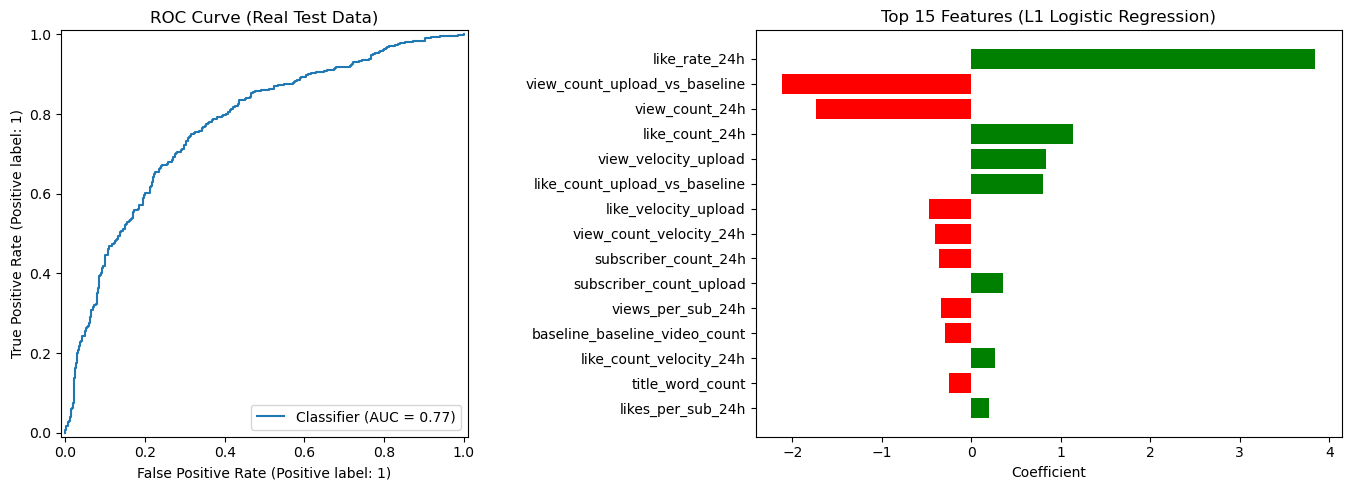

In [21]:
# === Visualizations ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[0])
axes[0].set_title('ROC Curve (Real Test Data)')

# Top 15 feature coefficients
top_15 = coef_df.head(15)
colors = ['green' if c > 0 else 'red' for c in top_15['coefficient']]
axes[1].barh(top_15['feature'], top_15['coefficient'], color=colors)
axes[1].set_xlabel('Coefficient')
axes[1].set_title('Top 15 Features (L1 Logistic Regression)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# === Model 2: Random Forest (scale-invariant, no scaling needed) ===

model_rf = RandomForestClassifier(random_state=42, n_jobs=-1, **RF_PARAMS)
model_rf.fit(X_train, y_train)

# Predictions on real-only test set
y_pred_rf = model_rf.predict(X_test)
y_pred_proba_rf = model_rf.predict_proba(X_test)[:, 1]

print("=" * 60)
print("Random Forest — Evaluated on Real Data Only")
print("=" * 60)
print(f"\nROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
print(f"\n{classification_report(y_test, y_pred_rf, target_names=['Below Baseline', 'Above Baseline'])}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_rf)}")

In [23]:
# === RF Feature Importance ===

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_rf.feature_importances_,
}).sort_values('importance', ascending=False)

print("Top 20 Features (Random Forest):")
print(importance_df.head(20).to_string(index=False))

Top 20 Features (Random Forest):
                      feature  importance
                like_rate_24h    0.078502
               view_count_24h    0.049415
      view_count_velocity_24h    0.043772
            views_per_sub_24h    0.041567
            likes_per_sub_24h    0.040152
               like_count_24h    0.037988
          view_velocity_ratio    0.035955
             duration_seconds    0.032137
      like_count_velocity_24h    0.032107
             like_rate_upload    0.030288
view_count_upload_vs_baseline    0.029649
like_count_upload_vs_baseline    0.028287
         likes_per_sub_upload    0.026577
            view_count_upload    0.026436
         views_per_sub_upload    0.025433
                   brightness    0.022503
                 colorfulness    0.022472
         subscriber_count_24h    0.021719
      subscriber_count_upload    0.021370
            like_count_upload    0.020684


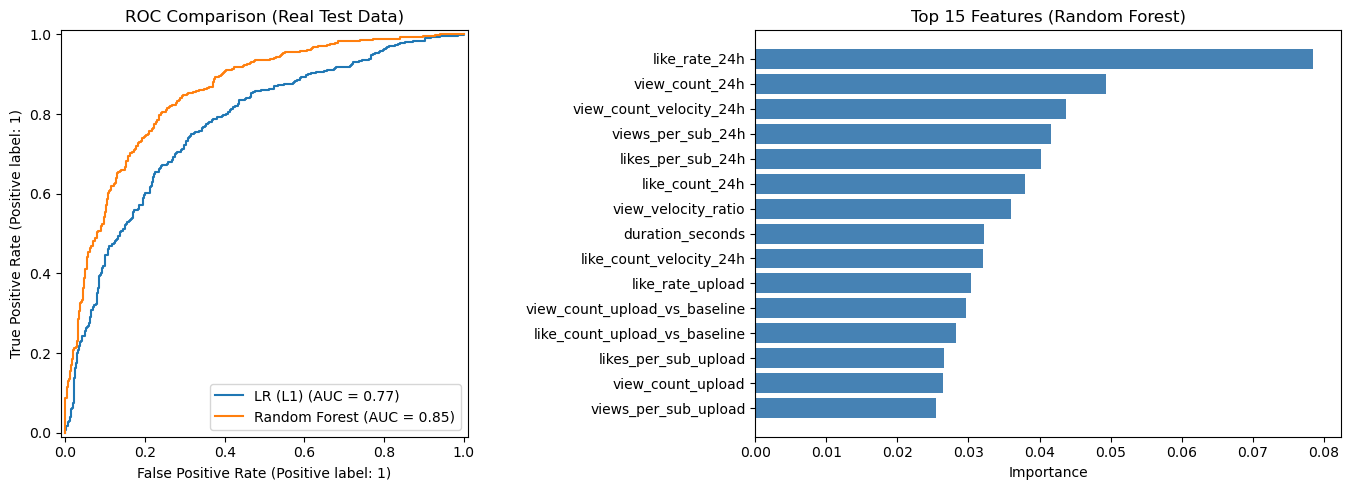

In [24]:
# === Side-by-side comparison ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves compared
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[0], name='LR (L1)')
RocCurveDisplay.from_predictions(y_test, y_pred_proba_rf, ax=axes[0], name='Random Forest')
axes[0].set_title('ROC Comparison (Real Test Data)')

# RF top 15 feature importances
top_15_rf = importance_df.head(15)
axes[1].barh(top_15_rf['feature'], top_15_rf['importance'], color='steelblue')
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 15 Features (Random Forest)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# === Model 3: XGBoost ===

model_xgb = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss', **XGB_PARAMS)
model_xgb.fit(X_train, y_train)

# Predictions on real-only test set
y_pred_xgb = model_xgb.predict(X_test)
y_pred_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

print("=" * 60)
print("XGBoost — Evaluated on Real Data Only")
print("=" * 60)
print(f"\nROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")
print(f"\n{classification_report(y_test, y_pred_xgb, target_names=['Below Baseline', 'Above Baseline'])}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_xgb)}")

In [26]:
# === XGBoost Feature Importance ===

importance_df_xgb = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_xgb.feature_importances_,
}).sort_values('importance', ascending=False)

print("Top 20 Features (XGBoost):")
print(importance_df_xgb.head(20).to_string(index=False))

Top 20 Features (XGBoost):
                      feature  importance
baseline_baseline_video_count    0.069370
                like_rate_24h    0.046162
               like_count_24h    0.035343
               view_count_24h    0.032945
                     is_short    0.032118
view_count_upload_vs_baseline    0.028052
like_count_upload_vs_baseline    0.026012
                desc_category    0.024887
               title_category    0.024417
          view_velocity_ratio    0.024003
      view_count_velocity_24h    0.023261
            views_per_sub_24h    0.021933
      like_count_velocity_24h    0.021401
            likes_per_sub_24h    0.021368
           desc_hashtag_count    0.021287
              duration_bucket    0.019854
             title_word_count    0.019804
             like_rate_upload    0.019789
                      is_long    0.019730
    view_velocity_per_sub_24h    0.019071


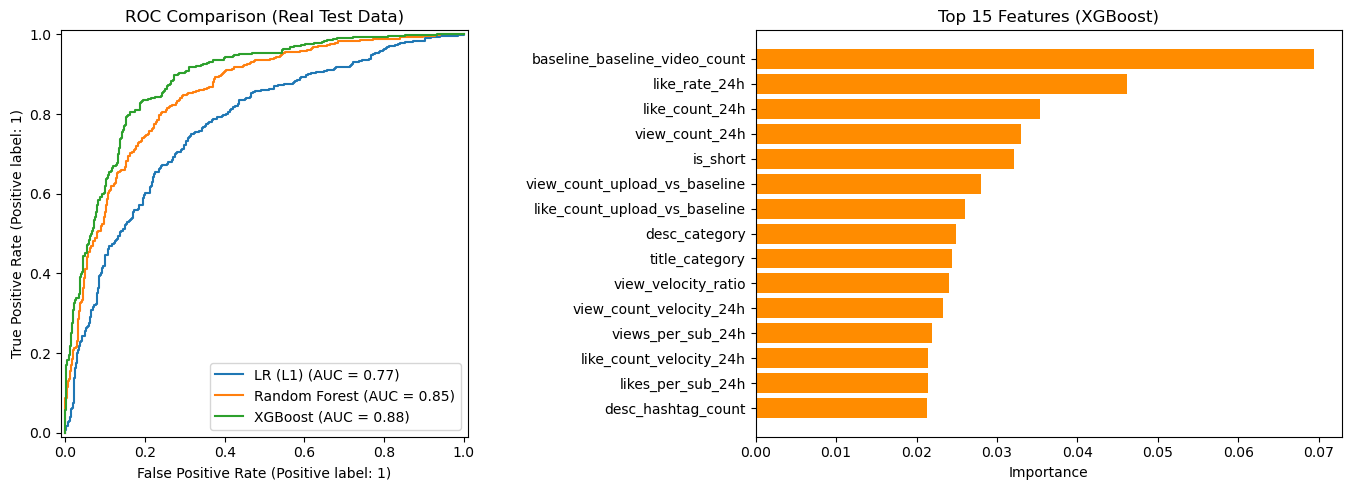

In [27]:
# === All three models compared ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[0], name='LR (L1)')
RocCurveDisplay.from_predictions(y_test, y_pred_proba_rf, ax=axes[0], name='Random Forest')
RocCurveDisplay.from_predictions(y_test, y_pred_proba_xgb, ax=axes[0], name='XGBoost')
axes[0].set_title('ROC Comparison (Real Test Data)')

top_15_xgb = importance_df_xgb.head(15)
axes[1].barh(top_15_xgb['feature'], top_15_xgb['importance'], color='darkorange')
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 15 Features (XGBoost)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [28]:
# === Model comparison table: precision, recall, F1, support, accuracy, AUC ===

def _model_report(name, y_true, y_pred, y_pred_proba):
    r = classification_report(
        y_true, y_pred,
        target_names=['Below Baseline', 'Above Baseline'],
        output_dict=True,
    )
    return {
        ('Below Baseline', 'Precision'): round(r['Below Baseline']['precision'], 3),
        ('Below Baseline', 'Recall'):    round(r['Below Baseline']['recall'], 3),
        ('Below Baseline', 'F1'):        round(r['Below Baseline']['f1-score'], 3),
        ('Below Baseline', 'Support'):   int(r['Below Baseline']['support']),
        ('Above Baseline', 'Precision'): round(r['Above Baseline']['precision'], 3),
        ('Above Baseline', 'Recall'):    round(r['Above Baseline']['recall'], 3),
        ('Above Baseline', 'F1'):        round(r['Above Baseline']['f1-score'], 3),
        ('Above Baseline', 'Support'):   int(r['Above Baseline']['support']),
        ('Overall', 'Accuracy'):         round(r['accuracy'], 3),
        ('Overall', 'ROC-AUC'):          round(roc_auc_score(y_true, y_pred_proba), 3),
    }

rows = {
    'LR (L1)':        _model_report('LR (L1)',       y_test, y_pred,     y_pred_proba),
    'Random Forest':  _model_report('Random Forest', y_test, y_pred_rf,  y_pred_proba_rf),
    'XGBoost':        _model_report('XGBoost',       y_test, y_pred_xgb, y_pred_proba_xgb),
}

df_comparison = pd.DataFrame(rows).T
df_comparison.index.name = 'Model'
df_comparison.columns = pd.MultiIndex.from_tuples(df_comparison.columns)

# Highlight best value per column (excluding Support, which is fixed)
highlight_cols = [c for c in df_comparison.columns if c[1] != 'Support']
df_comparison.style \
    .highlight_max(subset=highlight_cols, color='#d4edda') \
    .format({c: '{:.3f}' for c in highlight_cols})

In [ ]:
training_data = TrainingData.from_splits(X_train, y_train, X_test, y_test, X_synth)

if config.take_snapshot_hyperparams:
    save_hyperparams(
        params={
            'LogisticRegression':     LR_PARAMS,
            'RandomForestClassifier': RF_PARAMS,
            'XGBClassifier':          XGB_PARAMS,
        },
        version_tag=config.hyperparam_version,
        search_config=config.search_config,
        notes=f"Tuned on {config.mixed_version} training data",
    )

if config.take_snapshot_models:
    result_lr_ = ModelResult.from_sklearn(model_lr, X_test_scaled, y_test, feature_cols)
    model_config_lr_ = ModelConfig.from_model(model_lr)
    save_model(
        model=model_lr,
        scaler=scaler,
        feature_cols=feature_cols,
        version_tag=f"{config.model_version}_lr_l1",
        data_snapshot_tag=config.mixed_version,
        training_data=training_data,
        result=result_lr_,
        config=model_config_lr_,
        notes="LR L1 baseline, all 7d features excluded",
    )

    result_rf_ = ModelResult.from_sklearn(model_rf, X_test, y_test, feature_cols)
    model_config_rf_ = ModelConfig.from_model(model_rf)
    save_model(
        model=model_rf,
        scaler=None,
        feature_cols=feature_cols,
        version_tag=f"{config.model_version}_rf",
        data_snapshot_tag=config.mixed_version,
        training_data=training_data,
        result=result_rf_,
        config=model_config_rf_,
        notes="Random Forest, unscaled features",
    )

    result_xgb_ = ModelResult.from_sklearn(model_xgb, X_test, y_test, feature_cols)
    model_config_xgb_ = ModelConfig.from_model(model_xgb)
    save_model(
        model=model_xgb,
        scaler=None,
        feature_cols=feature_cols,
        version_tag=f"{config.model_version}_xgb",
        data_snapshot_tag=config.mixed_version,
        training_data=training_data,
        result=result_xgb_,
        config=model_config_xgb_,
        notes="XGBoost, unscaled features",
    )

# Compare all saved models
list_models()

In [7]:
# === Cross-version model comparison (all saved snapshots) ===

df_all_models = compare_models()

metric_cols = ['accuracy', 'roc_auc', 'f1_above', 'f1_below', 'precision_above', 'recall_above', 'precision_below', 'recall_below']

df_all_models.style \
    .highlight_max(subset=metric_cols, color='#d4edda') \
    .highlight_min(subset=metric_cols, color='#f8d7da') \
    .format({c: '{:.3f}' for c in metric_cols})

Loaded 12 model snapshots


,model_type,data_snapshot,training_date,real_rows,synth_rows,accuracy,roc_auc,precision_above,recall_above,f1_above,precision_below,recall_below,f1_below
version,,,,,,,,,,,,,
v1.0_lr_l1,LogisticRegression,v1.0_model_mixed66,2026-03-26,2100,5000,0.630,0.626,0.637,0.808,0.712,0.615,0.399,0.484
v1.0_rf,RandomForest,v1.0_model_mixed66,2026-03-26,2100,5000,0.695,0.759,0.716,0.764,0.739,0.663,0.605,0.633
v1.0_xgb,XGBoost,v1.0_model_mixed66,2026-03-26,2100,5000,0.711,0.770,0.756,0.721,0.738,0.657,0.697,0.677
v2.0_lr_l1,LogisticRegression,v2.0_mixed_70real,2026-03-26,3255,1743,0.623,0.646,0.636,0.771,0.697,0.595,0.433,0.501
v2.0_rf,RandomForest,v2.0_mixed_70real,2026-03-26,3255,1743,0.733,0.797,0.732,0.830,0.778,0.736,0.610,0.667
v2.0_xgb,XGBoost,v2.0_mixed_70real,2026-03-26,3255,1743,0.730,0.797,0.741,0.799,0.769,0.713,0.640,0.675
v3.0_lr_l1,LogisticRegression,v3.0_mixed_80real,2026-03-28,4037,1261,0.641,0.656,0.642,0.813,0.717,0.638,0.421,0.507
v3.0_rf,RandomForest,v3.0_mixed_80real,2026-03-28,4037,1261,0.760,0.825,0.757,0.843,0.798,0.766,0.655,0.706
v3.0_xgb,XGBoost,v3.0_mixed_80real,2026-03-28,4037,1261,0.762,0.830,0.779,0.804,0.791,0.739,0.710,0.724


Found 1 hyperparameter snapshots:

  v3.1  |  2026-03-30
    Notes: Default params for v3.1 models (pre-tuning baseline, no search run)
    LogisticRegression: {'C': 1.0, 'penalty': 'l1', 'solver': 'saga', 'max_iter': 5000}
    RandomForestClassifier: {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2, 'max_features': 'sqrt'}
    XGBClassifier: {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5}



In [ ]:
# === Commit version numbers to GCS after all snapshots succeed ===
# Only writes if any snapshots were active this run.
config.commit()

# === Inventory ===
# snapshot.list_snapshots()
# list_models()
# list_hyperparams()